# NuAncestor Scheduling Analysis

This notebook first evaluates whether two closely located telescope stations can each receive a continuous 30-minute NuAncestor observation every other night.

The telescope pair was selected from the supplied spectrograph list using great-circle distance. By default, only present visible spectrographs on independent telescope resources are considered. FreeFlyer `InContact.txt` and `IsNight.txt` outputs are then used to identify complete nights, continuous valid contact windows, feasible two-station schedules, and cadence violations.

The conservative default assumes that the two 30-minute observations may not overlap. “Every other night” is interpreted as allowing at most one consecutive complete night without a scheduled observation.

The scheduling analysis is also extended to 3-telescope regions: HARPS, CORALIE and ESPRESSO in Chile, and KPF, HIRES and MAROONX in Hawaii. For each region, the analysis evaluates individual telescope access, two-telescope joint feasibility, three-telescope joint feasibility and compliance with the every-other-night observing requirement.

Version 07/2026 by Pedro de S. C. Leonardo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display

## 2-Telescope Analysis:

In [2]:
# Settings to change for 2-telescope !!

# Main folder containing the FreeFlyer simulation results for 2-telescope
BASE = Path("All_Results/Scheduling/2-telescope")


CASE = {"name": "a = 23,200 km, i = 0°",
    "semi_major_axis": 23200,
    "inclination": 0,
    "folder": "Results_a23200_i0"}
    
"""CASE = {"name": "a = 23,200 km, i = 20°",
    "semi_major_axis": 23200,
    "inclination": 20,
    "folder": "Results_a23200_i20"}"""

DAYS = 365
MIN_OBSERVATION_H = 0.5  # 30 minutes
MAX_CONSECUTIVE_MISSED_NIGHTS = 1  # Every-other-night requirement

# Conservative setting: the two telescope slots cannot overlap
ALLOW_SIMULTANEOUS_OBSERVATIONS = False
COMMON_NIGHT_MODE = "intersection"  # "intersection" or "union"
# intersection = time is included only when it is night at both stations
# union = time is included when it is night at either station

EXCLUDE_PARTIAL_EDGE_NIGHTS = True

# FreeFlyer output handling
TIME_MATCH_TOLERANCE_S = 1.0
GAP_FACTOR = 1.5  # A larger gap breaks a continuous interval
# for 30-second step, gap greater than 45 seconds breaks the contact
# prevents the code from treating missing data as continuous visibility

# Telescopes included in the individual requirement table
REQUIREMENT_TELESCOPES = [
    "Chile", "La Palma", "Hawaii", "SALT", "DAG",
    "HARPS", "CORALIE"]

REQUIREMENT_COLUMNS = {
    "Chile": 1,
    "La Palma": 2,
    "Hawaii": 3,
    "SALT": 4,
    "DAG": 5,
    "HARPS": 6,
    "CORALIE": 7}

# InContact.txt and IsNight.txt column order:
# time, Chile, LaPalma, Hawaii, SALT, DAG, HARPS, CORALIE
STATION_NAMES = ["HARPS", "CORALIE"]
STATION_COLUMNS = [6, 7]

# range shown in plots -> can go up to 365 days
PLOT_START_NIGHT = 1
PLOT_END_NIGHT = 60

SAVE_TABLES = False
SAVE_FIGURES = False

In [3]:
# Contact time & invalid night summary table for the selected telescope pair

def read_result(folder, filename):
    """Read and clean one FreeFlyer results file."""
    path = BASE / folder / filename

    if not path.exists():
        raise FileNotFoundError(f"Result file not found: {path}")

    data = pd.read_csv(
        path, skiprows=3, sep=r"\s+", header=None,
        engine="python", dtype=str)

    # Remove repeated headers or other non-numeric lines
    data = data.apply(pd.to_numeric, errors="coerce").dropna(how="any")

    if data.empty:
        raise ValueError(f"No numeric data were found in {path}.")

    return (
        data.sort_values(0)
        .drop_duplicates(subset=0, keep="last")
        .to_numpy(dtype=float))


def infer_individual_simulation_end(time):
    """Infer the simulation end time from the output samples."""
    if len(time) < 2:
        raise ValueError("At least two output time samples are required.")

    time_steps = np.diff(time)

    if not np.all(time_steps > 0):
        raise ValueError("Output times must be strictly increasing.")

    return min(DAYS, time[-1] + np.median(time_steps))


def get_individual_boolean_intervals(time, state, simulation_end):
    """Return the start and end times of each continuous True interval."""
    state = np.asarray(state, dtype=bool)

    if len(time) != len(state):
        raise ValueError("Time and Boolean state arrays must have equal lengths.")

    time_steps = np.diff(time)
    nominal_dt = np.median(time_steps)
    gap_limit = GAP_FACTOR * nominal_dt

    intervals = []
    start = None

    for i, active in enumerate(state):
        if active and start is None:
            start = time[i]

        if not active:
            continue

        is_last = i == len(state) - 1
        large_gap = (
            not is_last and time[i + 1] - time[i] > gap_limit)
        state_ends = (
            not is_last and not state[i + 1])

        if is_last or large_gap or state_ends:
            if is_last:
                end = simulation_end
            elif large_gap:
                end = min(time[i] + nominal_dt, time[i + 1])
            else:
                end = time[i + 1]

            if end > start:
                intervals.append((start, end))

            start = None

    if len(intervals) == 0:
        return np.array([]), np.array([])

    intervals = np.array(intervals)

    return intervals[:, 0], intervals[:, 1]


def get_individual_night_intervals(time, is_night, simulation_end):
    """Return the complete nighttime intervals for one telescope."""
    night_starts, night_ends = get_individual_boolean_intervals(
        time, is_night, simulation_end)

    keep = np.ones(len(night_starts), dtype=bool)

    if EXCLUDE_PARTIAL_EDGE_NIGHTS and len(night_starts) > 0:
        if is_night[0]:
            keep[0] = False
        if is_night[-1]:
            keep[-1] = False

    return night_starts[keep], night_ends[keep]


def get_individual_missed_night_runs(night_has_valid_contact):
    """Return inclusive ranges of consecutive nights without valid contact."""
    runs = []
    run_start = None

    for night_index, has_contact in enumerate(night_has_valid_contact):
        if not has_contact and run_start is None:
            run_start = night_index
        elif has_contact and run_start is not None:
            runs.append((run_start, night_index - 1))
            run_start = None

    if run_start is not None:
        runs.append((run_start, len(night_has_valid_contact) - 1))

    return runs


def calculate_total_contact_time(time, visible, simulation_end):
    """Return the total continuous contact time in hours."""
    contact_starts, contact_ends = get_individual_boolean_intervals(
        time, visible, simulation_end)

    return np.sum(contact_ends - contact_starts) * 24


def count_individual_invalid_nights(
    time, visible, is_night, simulation_end):
    """Return the number of nights violating the observing cadence."""
    night_starts, night_ends = get_individual_night_intervals(
        time, is_night, simulation_end)

    if len(night_starts) == 0:
        raise ValueError("No complete nighttime intervals were found.")

    contact_starts, contact_ends = get_individual_boolean_intervals(
        time, visible, simulation_end)

    night_has_valid_contact = np.zeros(len(night_starts), dtype=bool)

    for night_index, (night_start, night_end) in enumerate(
        zip(night_starts, night_ends)):

        overlap_starts = np.maximum(contact_starts, night_start)
        overlap_ends = np.minimum(contact_ends, night_end)
        overlap_durations_h = np.maximum(
            0, overlap_ends - overlap_starts) * 24

        night_has_valid_contact[night_index] = np.any(
            overlap_durations_h >= MIN_OBSERVATION_H - 1e-9)

    missed_runs = get_individual_missed_night_runs(
        night_has_valid_contact)

    return sum(
        max(0, end - start + 1 - MAX_CONSECUTIVE_MISSED_NIGHTS)
        for start, end in missed_runs)


def create_simulation_summary(case):
    """Create the individual telescope summary for one orbit case."""
    folder = case["folder"]

    if len(STATION_NAMES) != 2 or len(STATION_COLUMNS) != 2:
        raise ValueError(
            "STATION_NAMES and STATION_COLUMNS must each contain "
            "exactly two entries.")

    contact_data = read_result(folder, "InContact.txt")
    night_data = read_result(folder, "IsNight.txt")

    required_column = max(STATION_COLUMNS)

    if contact_data.shape[1] <= required_column:
        raise ValueError(
            f"InContact.txt in {folder} does not contain columns "
            f"{STATION_COLUMNS}. Found {contact_data.shape[1]} columns.")

    if night_data.shape[1] <= required_column:
        raise ValueError(
            f"IsNight.txt in {folder} does not contain columns "
            f"{STATION_COLUMNS}. Found {night_data.shape[1]} columns.")

    contact = pd.DataFrame({
        "time": contact_data[:, 0],
        "visible_0": contact_data[:, STATION_COLUMNS[0]],
        "visible_1": contact_data[:, STATION_COLUMNS[1]]})

    night = pd.DataFrame({
        "time": night_data[:, 0],
        "night_0": night_data[:, STATION_COLUMNS[0]],
        "night_1": night_data[:, STATION_COLUMNS[1]]})

    contact = contact[
        (contact["time"] >= 0) & (contact["time"] < DAYS)]
    night = night[
        (night["time"] >= 0) & (night["time"] < DAYS)]

    merged = pd.merge_asof(
        contact.sort_values("time"),
        night.sort_values("time"),
        on="time", direction="nearest",
        tolerance=TIME_MATCH_TOLERANCE_S / 86400)

    unmatched = merged[["night_0", "night_1"]].isna().any(axis=1)

    if unmatched.any():
        raise ValueError(
            f"{unmatched.sum()} contact rows could not be matched to "
            "IsNight.txt within TIME_MATCH_TOLERANCE_S.")

    time = merged["time"].to_numpy()
    simulation_end = infer_individual_simulation_end(time)
    summary_rows = []

    for i, telescope in enumerate(STATION_NAMES):
        visible = merged[f"visible_{i}"].to_numpy() >= 0.5
        is_night = merged[f"night_{i}"].to_numpy() >= 0.5

        summary_rows.append({
            "Telescope": telescope,
            "Total contact [h]": calculate_total_contact_time(
                time, visible, simulation_end),
            "Invalid Nights": count_individual_invalid_nights(
                time, visible, is_night, simulation_end)})

    return pd.DataFrame(summary_rows).round(2)


# Display the individual results for the selected CASE
simulation_summary = create_simulation_summary(CASE)

print(f"\nSimulation: {CASE['name']}")
print(f"Folder: {BASE / CASE['folder']}")
display(simulation_summary.style.hide(axis="index"))


Simulation: a = 23,200 km, i = 0°
Folder: All_Results/Scheduling/2-telescope/Results_a23200_i0


Telescope,Total contact [h],Invalid Nights
HARPS,447.060000,0
CORALIE,447.030000,0


In [4]:
# Main file loading and alignment functions

def read_result(folder, filename):
    """Read and clean one FreeFlyer results file."""
    path = BASE / folder / filename

    if not path.exists():
        raise FileNotFoundError(f"Result file not found: {path}")

    data = pd.read_csv(
        path, skiprows=3, sep=r"\s+", header=None,
        engine="python", dtype=str)

    # Remove repeated headers or other non-numeric lines
    data = data.apply(pd.to_numeric, errors="coerce").dropna(how="any")

    if data.empty:
        raise ValueError(f"No numeric data were found in {path}.")

    data = (
        data.sort_values(0)
        .drop_duplicates(subset=0, keep="last")
        .to_numpy(dtype=float))

    return data


def load_case_results(case):
    """Read, align and validate contact and nighttime results."""
    folder = case["folder"]
    contact_data = read_result(folder, "InContact.txt")
    night_data = read_result(folder, "IsNight.txt")

    if contact_data.shape[1] <= max(STATION_COLUMNS):
        raise ValueError(
            f"InContact.txt in {folder} does not contain columns "
            f"{STATION_COLUMNS}. Found {contact_data.shape[1]} columns.")

    if night_data.shape[1] <= max(STATION_COLUMNS):
        raise ValueError(
            f"IsNight.txt in {folder} does not contain columns "
            f"{STATION_COLUMNS}. Found {night_data.shape[1]} columns.")

    contact = pd.DataFrame({
        "time": contact_data[:, 0],
        "visible_0": contact_data[:, STATION_COLUMNS[0]],
        "visible_1": contact_data[:, STATION_COLUMNS[1]]})

    night = pd.DataFrame({
        "time": night_data[:, 0],
        "night_0": night_data[:, STATION_COLUMNS[0]],
        "night_1": night_data[:, STATION_COLUMNS[1]]})

    contact = contact[
        (contact["time"] >= 0) & (contact["time"] < DAYS)]
    night = night[
        (night["time"] >= 0) & (night["time"] < DAYS)]

    merged = pd.merge_asof(
        contact.sort_values("time"),
        night.sort_values("time"),
        on="time", direction="nearest",
        tolerance=TIME_MATCH_TOLERANCE_S / 86400)

    unmatched = merged[["night_0", "night_1"]].isna().any(axis=1)

    if unmatched.any():
        raise ValueError(
            f"{unmatched.sum()} contact rows could not be matched to "
            "IsNight.txt within TIME_MATCH_TOLERANCE_S.")

    time = merged["time"].to_numpy()
    visible = merged[["visible_0", "visible_1"]].to_numpy() >= 0.5
    is_night = merged[["night_0", "night_1"]].to_numpy() >= 0.5

    if len(time) < 2:
        raise ValueError("At least two matched output samples are required.")

    if not np.all(np.diff(time) > 0):
        raise ValueError("Output times remain non-increasing after cleaning.")

    return time, visible, is_night

In [5]:
# Scheduling helper functions
# This cell contains most of the scheduling logic

def infer_time_properties(time):
    """Infer nominal timing without requiring an exactly fixed step."""
    time_steps = np.diff(time)
    nominal_dt = np.median(time_steps)
    simulation_end = min(DAYS, time[-1] + nominal_dt)

    return {
        "nominal_dt": nominal_dt,
        "simulation_end": simulation_end,
        "median_step_s": nominal_dt * 86400,
        "minimum_step_s": np.min(time_steps) * 86400,
        "maximum_step_s": np.max(time_steps) * 86400}


def get_state_intervals(time, state, simulation_end, nominal_dt):
    """Return continuous True intervals using the actual timestamps."""
    state = np.asarray(state, dtype=bool)
    intervals = []
    start = None
    gap_limit = GAP_FACTOR * nominal_dt

    for i, active in enumerate(state):
        if active and start is None:
            start = time[i]

        if not active:
            continue

        is_last = i == len(state) - 1
        large_gap = (
            not is_last and time[i + 1] - time[i] > gap_limit)
        state_ends = (
            not is_last and not state[i + 1])

        if is_last or large_gap or state_ends:
            if is_last:
                end = simulation_end
            elif large_gap:
                end = min(time[i] + nominal_dt, time[i + 1])
            else:
                end = time[i + 1]

            if end > start:
                intervals.append((start, end))

            start = None

    return intervals


def get_complete_nights(time, common_night, simulation_end, nominal_dt):
    """Return complete common-night intervals."""
    nights = get_state_intervals(
        time, common_night, simulation_end, nominal_dt)

    if not EXCLUDE_PARTIAL_EDGE_NIGHTS or not nights:
        return nights

    if common_night[0] and nights:
        nights = nights[1:]

    if common_night[-1] and nights:
        nights = nights[:-1]

    return nights


def clip_intervals(intervals, start, end):
    """Clip intervals to a single night."""
    clipped = []

    for interval_start, interval_end in intervals:
        clipped_start = max(interval_start, start)
        clipped_end = min(interval_end, end)

        if clipped_end > clipped_start:
            clipped.append((clipped_start, clipped_end))

    return clipped


def get_candidate_slots(intervals):
    """Return boundary slots for all windows lasting at least 30 minutes."""
    duration = MIN_OBSERVATION_H / 24
    tolerance = 1e-12
    slots = []

    for start, end in intervals:
        if end - start + tolerance < duration:
            continue

        slots.append((start, start + duration))
        latest_start = end - duration

        if latest_start > start + tolerance:
            slots.append((latest_start, end))

    return slots


def choose_joint_slots(first_slots, second_slots):
    """Choose the earliest feasible two-station slot combination."""
    if not first_slots or not second_slots:
        return None

    best = None

    for first_slot in first_slots:
        for second_slot in second_slots:
            non_overlapping = (
                first_slot[1] <= second_slot[0] + 1e-12
                or second_slot[1] <= first_slot[0] + 1e-12)

            if ALLOW_SIMULTANEOUS_OBSERVATIONS or non_overlapping:
                key = (
                    max(first_slot[1], second_slot[1]),
                    min(first_slot[0], second_slot[0]),
                    first_slot[0], second_slot[0])

                if best is None or key < best[0]:
                    best = (key, first_slot, second_slot)

    return None if best is None else (best[1], best[2])


def maximum_continuous_hours(intervals):
    """Return the longest continuous interval [h]."""
    if not intervals:
        return 0.0

    return max(end - start for start, end in intervals) * 24


def build_cadence_plan(feasible_nights):
    """Find the minimum-observation plan satisfying the cadence."""
    states = {0: (0, [])}

    for feasible in feasible_nights:
        next_states = {}

        for missed_nights, (count, plan) in states.items():
            if feasible:
                candidate = (count + 1, plan + [True])
                current = next_states.get(0)

                if current is None or candidate < current:
                    next_states[0] = candidate

            if missed_nights < MAX_CONSECUTIVE_MISSED_NIGHTS:
                new_missed_nights = missed_nights + 1
                candidate = (count, plan + [False])
                current = next_states.get(new_missed_nights)

                if current is None or candidate < current:
                    next_states[new_missed_nights] = candidate

        states = next_states

        if not states:
            return None

    return min(states.values())[1]


def longest_false_run(state):
    """Return the longest consecutive run of False values."""
    longest = 0
    current = 0

    for value in state:
        current = 0 if value else current + 1
        longest = max(longest, current)

    return longest


def elapsed_label(elapsed_days):
    """Format elapsed simulation time as day and clock time."""
    total_minutes = int(round(elapsed_days * 24 * 60))
    day = total_minutes // (24 * 60)
    hour = total_minutes % (24 * 60) // 60
    minute = total_minutes % 60

    return f"Day {day}, {hour:02d}:{minute:02d}" 

In [6]:
# Main joint scheduling calculation

def analyse_case(case):
    """Evaluate the two-station scheduling requirement for one orbit."""
    time, visible, is_night = load_case_results(case)
    timing = infer_time_properties(time)
    nominal_dt = timing["nominal_dt"]
    simulation_end = timing["simulation_end"]

    if COMMON_NIGHT_MODE == "intersection":
        common_night = is_night[:, 0] & is_night[:, 1]
    elif COMMON_NIGHT_MODE == "union":
        common_night = is_night[:, 0] | is_night[:, 1]
    else:
        raise ValueError(
            "COMMON_NIGHT_MODE must be 'intersection' or 'union'.")

    nights = get_complete_nights(
        time, common_night, simulation_end, nominal_dt)

    if not nights:
        raise ValueError(
            f"No complete common nights were found for {case['name']}.")

    station_intervals = [
        get_state_intervals(
            time, visible[:, i], simulation_end, nominal_dt)
        for i in range(2)]

    rows = []
    chosen_slots = []

    for night_number, (night_start, night_end) in enumerate(
        nights, start=1):

        first_intervals = clip_intervals(
            station_intervals[0], night_start, night_end)
        second_intervals = clip_intervals(
            station_intervals[1], night_start, night_end)

        first_slots = get_candidate_slots(first_intervals)
        second_slots = get_candidate_slots(second_intervals)
        joint_slots = choose_joint_slots(first_slots, second_slots)
        chosen_slots.append(joint_slots)

        rows.append({
            "Night": night_number,
            "Night start": elapsed_label(night_start),
            "Night end": elapsed_label(night_end),
            f"{STATION_NAMES[0]} max continuous [h]":
                maximum_continuous_hours(first_intervals),
            f"{STATION_NAMES[1]} max continuous [h]":
                maximum_continuous_hours(second_intervals),
            f"{STATION_NAMES[0]} ≥30 min": bool(first_slots),
            f"{STATION_NAMES[1]} ≥30 min": bool(second_slots),
            "Both individually feasible": bool(first_slots and second_slots),
            "Joint schedule feasible": joint_slots is not None})

    schedule = pd.DataFrame(rows)
    feasible_nights = schedule["Joint schedule feasible"].to_numpy()
    cadence_plan = build_cadence_plan(feasible_nights)
    cadence_satisfied = cadence_plan is not None

    if cadence_plan is None:
        cadence_plan = feasible_nights.tolist()

    schedule["Scheduled"] = cadence_plan
    schedule[f"{STATION_NAMES[0]} slot"] = ""
    schedule[f"{STATION_NAMES[1]} slot"] = ""

    for i, scheduled in enumerate(cadence_plan):
        if not scheduled:
            continue

        first_slot, second_slot = chosen_slots[i]
        schedule.loc[i, f"{STATION_NAMES[0]} slot"] = (
            f"{elapsed_label(first_slot[0])}–"
            f"{elapsed_label(first_slot[1])}")
        schedule.loc[i, f"{STATION_NAMES[1]} slot"] = (
            f"{elapsed_label(second_slot[0])}–"
            f"{elapsed_label(second_slot[1])}")

    summary = {
        "Case": case["name"],
        "Selected pair": f"{STATION_NAMES[0]} + {STATION_NAMES[1]}",
        "Matched output samples": len(time),
        "Median output step [s]": timing["median_step_s"],
        "Minimum output step [s]": timing["minimum_step_s"],
        "Maximum output step [s]": timing["maximum_step_s"],
        "Analysed complete nights": len(schedule),
        "Both individually feasible [nights]":
            int(schedule["Both individually feasible"].sum()),
        "Joint schedule feasible [nights]":
            int(schedule["Joint schedule feasible"].sum()),
        "Scheduled campaign nights": int(schedule["Scheduled"].sum()),
        "Longest run without joint feasibility [nights]":
            longest_false_run(feasible_nights),
        "Every-other-night requirement satisfied":
            "Yes" if cadence_satisfied else "No"}

    return summary, schedule

In [7]:
summary, selected_schedule = analyse_case(CASE)
scheduling_summary = pd.DataFrame([summary])

display(
    scheduling_summary
    .style.hide(axis="index"))

Case,Selected pair,Matched output samples,Median output step [s],Minimum output step [s],Maximum output step [s],Analysed complete nights,Both individually feasible [nights],Joint schedule feasible [nights],Scheduled campaign nights,Longest run without joint feasibility [nights],Every-other-night requirement satisfied
"a = 23,200 km, i = 0°",HARPS + CORALIE,1051200,29.999981,29.999981,30.000067,365,241,228,199,1,Yes


In [8]:
# Run the main analysis and display

"""
print(f"Scheduled nights for {CASE['name']}:")
display(
    selected_schedule[selected_schedule["Scheduled"]]
    .reset_index(drop=True)
    .round(3)
    .style.hide(axis="index"))

print("\nNights where a joint schedule is not possible:")
display(
    selected_schedule[~selected_schedule["Joint schedule feasible"]]
    .reset_index(drop=True)
    .round(3)
    .style.hide(axis="index"))
"""

'\nprint(f"Scheduled nights for {CASE[\'name\']}:")\ndisplay(\n    selected_schedule[selected_schedule["Scheduled"]]\n    .reset_index(drop=True)\n    .round(3)\n    .style.hide(axis="index"))\n\nprint("\nNights where a joint schedule is not possible:")\ndisplay(\n    selected_schedule[~selected_schedule["Joint schedule feasible"]]\n    .reset_index(drop=True)\n    .round(3)\n    .style.hide(axis="index"))\n'

In [9]:
# Save CSV tables

if SAVE_TABLES:
    output = BASE / "scheduling_tables"
    output.mkdir(parents=True, exist_ok=True)

    scheduling_summary.to_csv(
        output / "scheduling_summary.csv", index=False)
    selected_schedule.to_csv(
        output / "HARPS_CORALIE_schedule.csv", index=False)

Analysing a = 23,200 km, i = 0°...


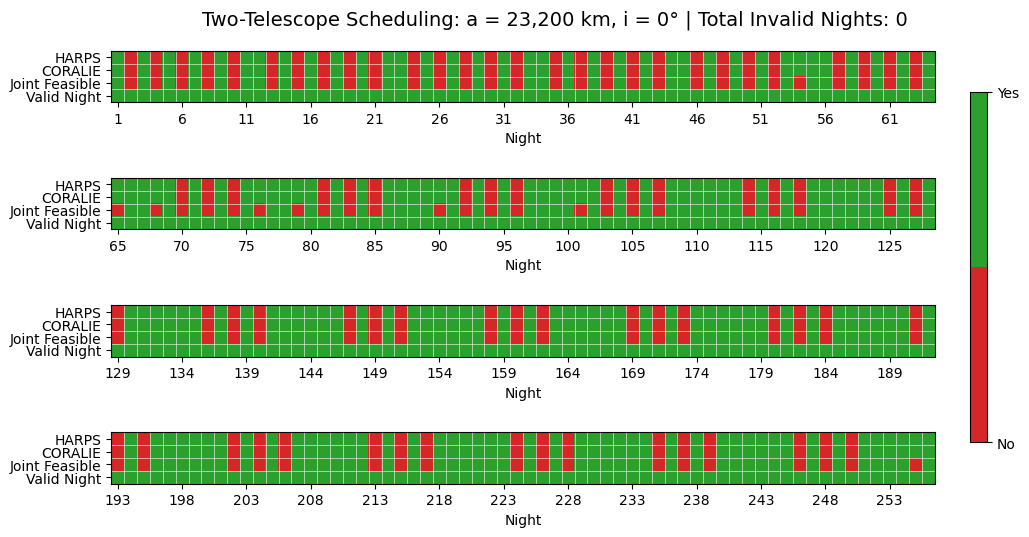

Analysing a = 23,200 km, i = 20°...


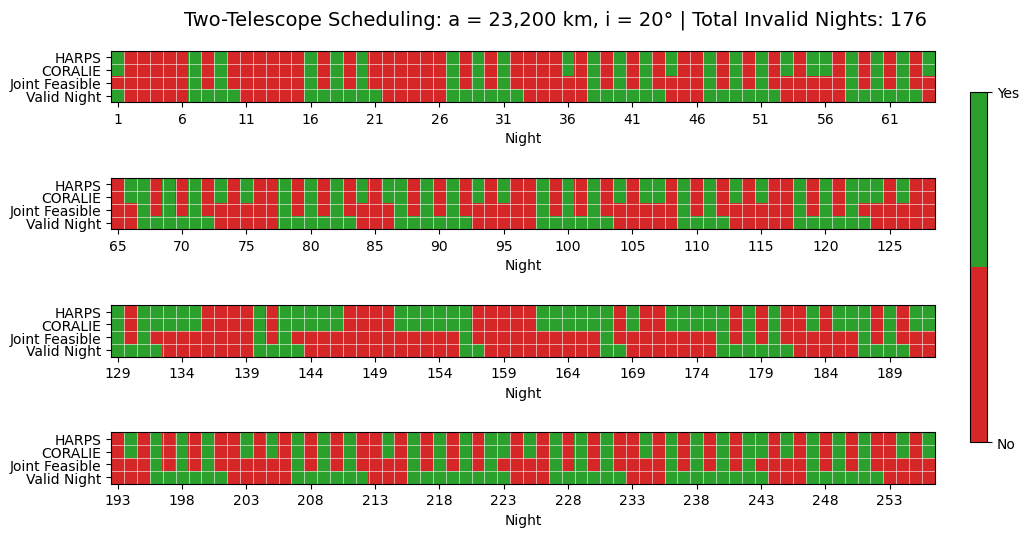

Analysing a = 23,200 km, i = 40°...


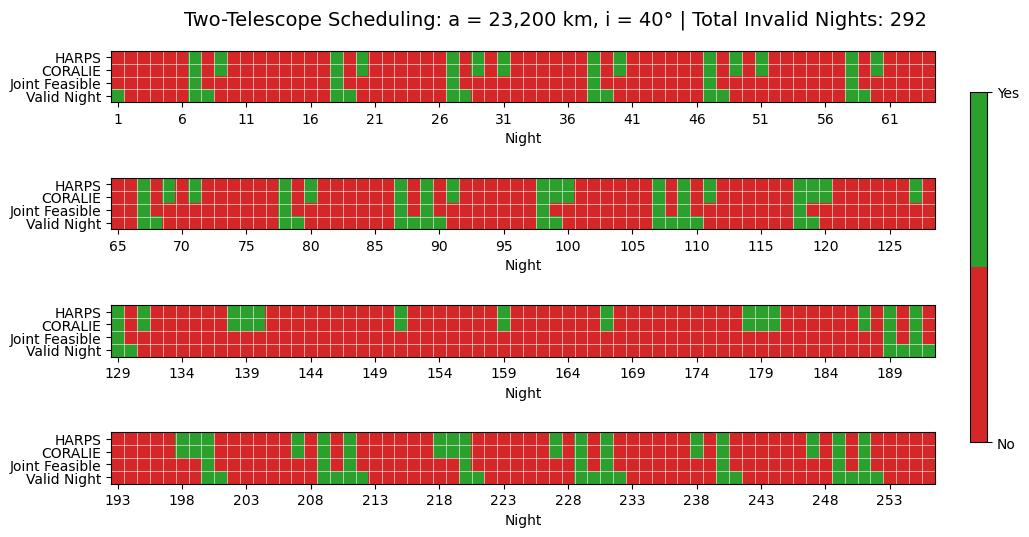

Analysing a = 28,750 km, i = 0°...


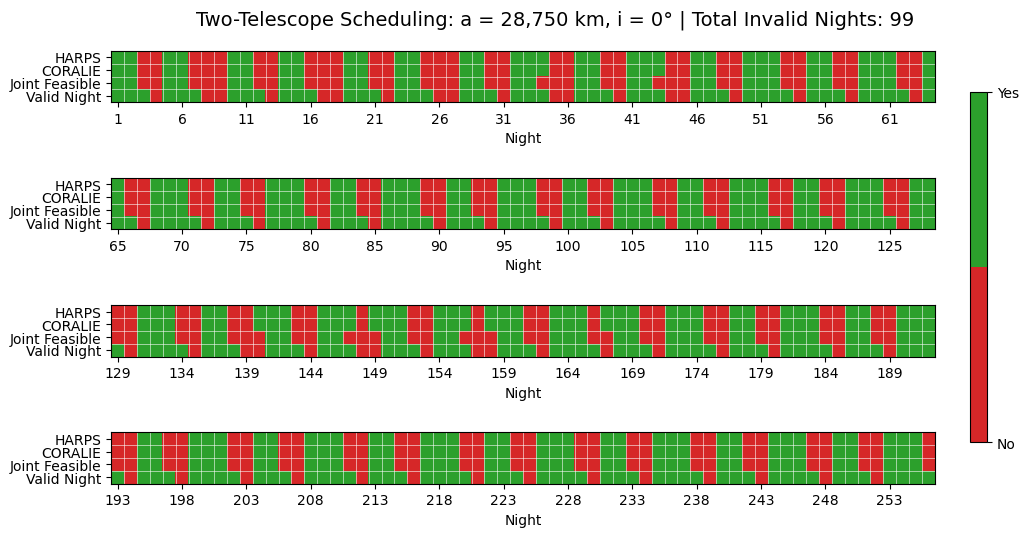

Analysing a = 28,750 km, i = 20°...


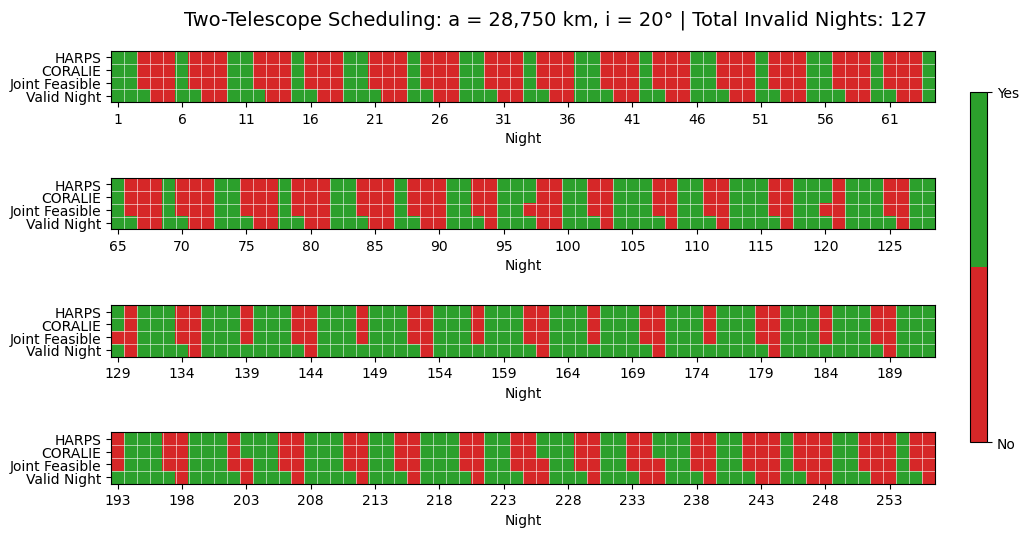

Analysing a = 28,750 km, i = 40°...


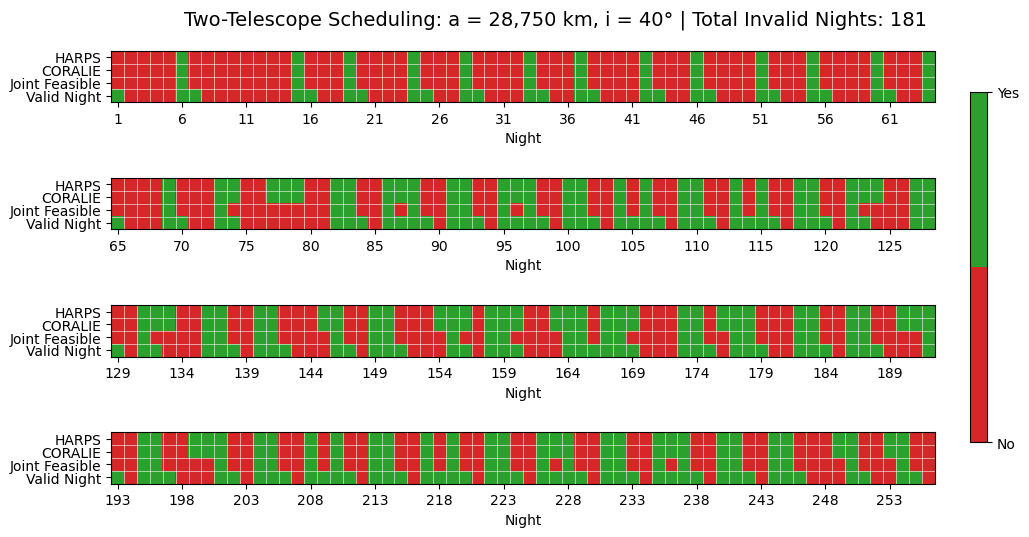

Semi-major axis [km],Inclination [deg],Invalid Nights
23200,0,0
23200,20,176
23200,40,292
28750,0,99
28750,20,127
28750,40,181


In [10]:
# Scheduling heatmaps for all orbit cases

from matplotlib.colors import ListedColormap

NIGHTS_PER_PLOT = 64
NUMBER_OF_PLOTS = 4

CASES = [
    {"name": "a = 23,200 km, i = 0°",
     "semi_major_axis": 23200,
     "inclination": 0,
     "folder": "Results_a23200_i0"},
    {"name": "a = 23,200 km, i = 20°",
     "semi_major_axis": 23200,
     "inclination": 20,
     "folder": "Results_a23200_i20"},
    {"name": "a = 23,200 km, i = 40°",
     "semi_major_axis": 23200,
     "inclination": 40,
     "folder": "Results_a23200_i40"},
    {"name": "a = 28,750 km, i = 0°",
     "semi_major_axis": 28750,
     "inclination": 0,
     "folder": "Results_a28750_i0"},
    {"name": "a = 28,750 km, i = 20°",
     "semi_major_axis": 28750,
     "inclination": 20,
     "folder": "Results_a28750_i20"},
    {"name": "a = 28,750 km, i = 40°",
     "semi_major_axis": 28750,
     "inclination": 40,
     "folder": "Results_a28750_i40"}]

status_columns = [
    f"{STATION_NAMES[0]} ≥{MIN_OBSERVATION_H * 60:g} min",
    f"{STATION_NAMES[1]} ≥{MIN_OBSERVATION_H * 60:g} min",
    "Joint schedule feasible",
    "Valid night"]

status_labels = [
    STATION_NAMES[0],
    STATION_NAMES[1],
    "Joint Feasible",
    "Valid Night"]

status_cmap = ListedColormap([
    "#d62728",  # No: red
    "#2ca02c"]) # Yes: green

all_scheduling_summaries = []
all_scheduling_schedules = {}
violation_summary_rows = []

for case in CASES:
    print(f"Analysing {case['name']}...")

    case_summary, case_schedule = analyse_case(case)
    case_schedule = case_schedule.copy()

    # A night is invalid from the second night of a joint-infeasible run
    joint_feasible = case_schedule[
        "Joint schedule feasible"].to_numpy(dtype=bool)

    invalid_night = np.zeros(len(case_schedule), dtype=bool)
    missed_run = 0

    for i, feasible_night in enumerate(joint_feasible):
        missed_run = 0 if feasible_night else missed_run + 1
        invalid_night[i] = (
            missed_run > MAX_CONSECUTIVE_MISSED_NIGHTS)

    case_schedule["Valid night"] = ~invalid_night

    total_joint_infeasible = int((~joint_feasible).sum())
    total_invalid_nights = int(invalid_night.sum())
    total_analysed_nights = len(case_schedule)

    case_summary["Joint-infeasible Nights"] = total_joint_infeasible
    case_summary["Invalid Nights"] = total_invalid_nights

    all_scheduling_summaries.append(case_summary)
    all_scheduling_schedules[case["folder"]] = case_schedule

    violation_summary_rows.append({
        "Semi-major axis [km]": case["semi_major_axis"],
        "Inclination [deg]": case["inclination"],
        "Invalid Nights": total_invalid_nights})

    plot_end_night = min(
        PLOT_START_NIGHT + NUMBER_OF_PLOTS * NIGHTS_PER_PLOT - 1,
        int(case_schedule["Night"].max()))

    fig, axes = plt.subplots(
        NUMBER_OF_PLOTS, 1, figsize=(12, 6),
        gridspec_kw={"hspace": 0.15})

    last_image = None
    plotted_any_data = False

    for plot_index, ax in enumerate(axes):
        start_night = PLOT_START_NIGHT + plot_index * NIGHTS_PER_PLOT
        end_night = min(
            start_night + NIGHTS_PER_PLOT - 1,
            plot_end_night)

        plot_schedule = case_schedule[
            (case_schedule["Night"] >= start_night)
            & (case_schedule["Night"] <= end_night)]

        if plot_schedule.empty:
            ax.set_visible(False)
            continue

        plotted_any_data = True
        status = plot_schedule[status_columns].to_numpy(dtype=int).T

        last_image = ax.imshow(
            status, aspect="equal", interpolation="nearest",
            cmap=status_cmap, vmin=0, vmax=1,
            extent=[
                plot_schedule["Night"].iloc[0] - 0.5,
                plot_schedule["Night"].iloc[-1] + 0.5,
                len(status_columns) - 0.5, -0.5])

        ax.set_xlabel("Night")
        ax.set_yticks(range(len(status_labels)))
        ax.set_yticklabels(status_labels)

        ax.set_xticks(np.arange(start_night, end_night + 1, 5))
        ax.set_xticks(
            np.arange(start_night - 0.5, end_night + 0.5, 1),
            minor=True)
        ax.set_yticks(
            np.arange(-0.5, len(status_labels), 1),
            minor=True)

        ax.grid(
            which="minor", color="white",
            linewidth=0.5, alpha=0.8)
        ax.tick_params(which="minor", bottom=False, left=False)

    if not plotted_any_data:
        plt.close(fig)
        raise ValueError(
            f"The selected plot-night range contains "
            f"no analysed nights for {case['name']}.")

    fig.suptitle(
        f"Two-Telescope Scheduling: {case['name']} | "
        f"Total Invalid Nights: {total_invalid_nights}",
        fontsize=14, y=0.92)

    fig.subplots_adjust(
        top=0.90, bottom=0.08, left=0.13,
        right=0.86, hspace=0.15)

    visible_axes = [ax for ax in axes if ax.get_visible()]

    colorbar = fig.colorbar(
        last_image, ax=visible_axes, location="right",
        ticks=[0, 1], fraction=0.02, pad=0.04)
    colorbar.ax.set_yticklabels(["No", "Yes"])

    if SAVE_FIGURES:
        output = BASE / "scheduling_plots"
        output.mkdir(parents=True, exist_ok=True)

        filename = (
            f"two_telescope_schedule_"
            f"a{case['semi_major_axis']}_"
            f"i{case['inclination']}.png")

        plt.savefig(
            output / filename,
            dpi=300, bbox_inches="tight")

    plt.show()

scheduling_summaries = pd.DataFrame(all_scheduling_summaries)
invalid_night_table = pd.DataFrame(violation_summary_rows)

display(
    invalid_night_table.style
    .hide(axis="index")
    .set_caption("Invalid Nights"))

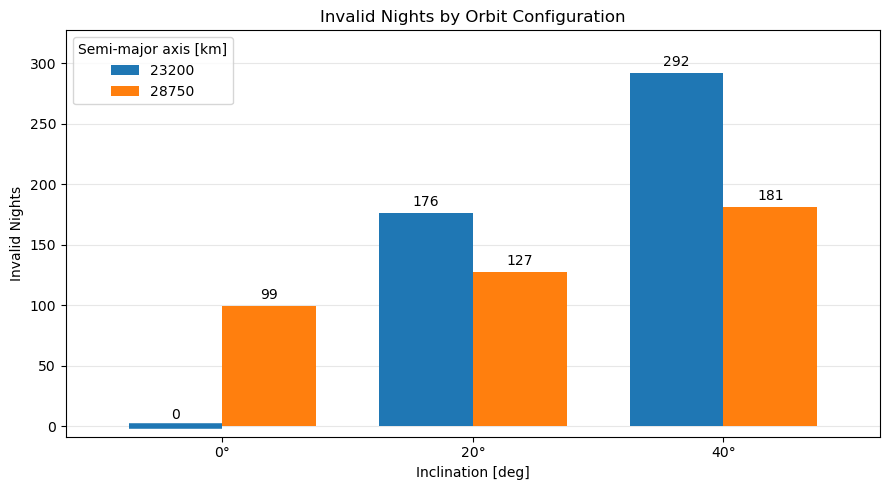

In [11]:
# Invalid nights for each orbit case

invalid_nights_plot = invalid_night_table.pivot(
    index="Inclination [deg]",
    columns="Semi-major axis [km]",
    values="Invalid Nights")

ax = invalid_nights_plot.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#1f77b4", "#ff7f0e"],
    width=0.75)

ax.set_title("Invalid Nights by Orbit Configuration")
ax.set_xlabel( "Inclination [deg]")
ax.set_ylabel("Invalid Nights")
ax.set_xticklabels(
    [f"{inclination:g}°"
     for inclination in invalid_nights_plot.index],
    rotation=0)
ax.legend(title="Semi-major axis [km]")

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

maximum_value = invalid_nights_plot.to_numpy().max()
ax.set_ylim(
    -max(0.5, maximum_value * 0.03),
    max(1, maximum_value * 1.12))

for container in ax.containers:
    ax.bar_label(container, padding=3)

    for bar, value in zip(
            container,
            container.datavalues):
        if value == 0:
            ax.hlines(
                y=0,
                xmin=bar.get_x(),
                xmax=bar.get_x() + bar.get_width(),
                color=bar.get_facecolor(),
                linewidth=4,
                zorder=4)

plt.tight_layout()

if SAVE_FIGURES:
    output = BASE / "scheduling_plots"
    output.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        output / "invalid_nights_by_orbit.png",
        dpi=300, bbox_inches="tight")

plt.show()

## 3-Telescope Analysis:

Definitions:
- 2-joint feasible: any two of the three regional telescopes can each receive a non-overlapping 30-minute observation.
- 3-joint feasible: all three regional telescopes can each receive a non-overlapping 30-minute observation.
- Joint-Feasible Chile/Hawaii in the first plot means 3-joint feasible.
- Valid Night Chile/Hawaii is calculated from 3-joint feasibility using the existing every-other-night requirement.

In [24]:
# Three-telescope regional scheduling settings

from itertools import combinations, permutations
from matplotlib.colors import ListedColormap

BASE = Path("All_Results/Scheduling/3-telescope")

# GroundStation order:
# Chile, LaPalma, Hawaii, SALT, DAG, HARPS, CORALIE,
# ESPRESSO, KPF, HIRES, MAROONX

# InContact.txt and IsNight.txt column order:
# time, Chile, LaPalma, Hawaii, SALT, DAG, HARPS, CORALIE,
# ESPRESSO, KPF, HIRES, MAROONX
REGIONAL_TELESCOPES = {
    "Chile": {
        "names": ["HARPS", "CORALIE", "ESPRESSO"],
        "columns": [6, 7, 8]},
    "Hawaii": {
        "names": ["KPF", "HIRES", "MAROONX"],
        "columns": [9, 10, 11]}}

THREE_TELESCOPE_NIGHTS_PER_PLOT = 64
THREE_TELESCOPE_NUMBER_OF_PLOTS = 4

CASES = [
    {"name": "a = 23,200 km, i = 0°",
     "semi_major_axis": 23200,
     "inclination": 0,
     "folder": "Results_a23200_i0"},
    {"name": "a = 23,200 km, i = 20°",
     "semi_major_axis": 23200,
     "inclination": 20,
     "folder": "Results_a23200_i20"},
    {"name": "a = 23,200 km, i = 40°",
     "semi_major_axis": 23200,
     "inclination": 40,
     "folder": "Results_a23200_i40"}]

""" 
    {"name": "a = 28,750 km, i = 0°",
     "semi_major_axis": 28750,
     "inclination": 0,
     "folder": "Results_a28750_i0"},
    {"name": "a = 28,750 km, i = 20°",
     "semi_major_axis": 28750,
     "inclination": 20,
     "folder": "Results_a28750_i20"},
    {"name": "a = 28,750 km, i = 40°",
     "semi_major_axis": 28750,
     "inclination": 40,
     "folder": "Results_a28750_i40"}"""

' \n    {"name": "a = 28,750 km, i = 0°",\n     "semi_major_axis": 28750,\n     "inclination": 0,\n     "folder": "Results_a28750_i0"},\n    {"name": "a = 28,750 km, i = 20°",\n     "semi_major_axis": 28750,\n     "inclination": 20,\n     "folder": "Results_a28750_i20"},\n    {"name": "a = 28,750 km, i = 40°",\n     "semi_major_axis": 28750,\n     "inclination": 40,\n     "folder": "Results_a28750_i40"}'

In [25]:
# Three-telescope regional scheduling functions

def load_three_telescope_results(case, station_columns):
    """Read, align and validate three-telescope regional results."""
    folder = case["folder"]
    contact_data = read_result(folder, "InContact.txt")
    night_data = read_result(folder, "IsNight.txt")

    if len(station_columns) != 3:
        raise ValueError(
            "Each regional telescope group must contain "
            "exactly three columns.")

    if contact_data.shape[1] <= max(station_columns):
        raise ValueError(
            f"InContact.txt in {folder} does not contain columns "
            f"{station_columns}. Found {contact_data.shape[1]} columns.")

    if night_data.shape[1] <= max(station_columns):
        raise ValueError(
            f"IsNight.txt in {folder} does not contain columns "
            f"{station_columns}. Found {night_data.shape[1]} columns.")

    contact = pd.DataFrame({
        "time": contact_data[:, 0],
        "visible_0": contact_data[:, station_columns[0]],
        "visible_1": contact_data[:, station_columns[1]],
        "visible_2": contact_data[:, station_columns[2]]})

    night = pd.DataFrame({
        "time": night_data[:, 0],
        "night_0": night_data[:, station_columns[0]],
        "night_1": night_data[:, station_columns[1]],
        "night_2": night_data[:, station_columns[2]]})

    contact = contact[(contact["time"] >= 0) & (contact["time"] < DAYS)]
    night = night[(night["time"] >= 0) & (night["time"] < DAYS)]

    merged = pd.merge_asof(
        contact.sort_values("time"),
        night.sort_values("time"),
        on="time", direction="nearest",
        tolerance=TIME_MATCH_TOLERANCE_S / 86400)

    unmatched = merged[["night_0", "night_1", "night_2"]].isna().any(axis=1)

    if unmatched.any():
        raise ValueError(
            f"{unmatched.sum()} contact rows could not be matched to "
            "IsNight.txt within TIME_MATCH_TOLERANCE_S.")

    time = merged["time"].to_numpy()
    visible = merged[["visible_0", "visible_1", "visible_2"]].to_numpy() >= 0.5
    is_night = merged[["night_0", "night_1", "night_2"]].to_numpy() >= 0.5

    if len(time) < 2:
        raise ValueError("At least two matched output samples are required.")

    if not np.all(np.diff(time) > 0):
        raise ValueError("Output times remain non-increasing after cleaning.")

    return time, visible, is_night


def get_earliest_regional_slot(intervals, earliest_start):
    """Return the earliest fixed-duration slot after a given time."""
    duration = MIN_OBSERVATION_H / 24
    tolerance = 1e-12

    for start, end in intervals:
        slot_start = max(start, earliest_start)
        slot_end = slot_start + duration

        if slot_end <= end + tolerance:
            return slot_start, slot_end

    return None


def choose_regional_slots(station_intervals, required_telescopes):
    """Choose the earliest feasible regional telescope combination."""
    telescope_indices = range(len(station_intervals))
    best = None

    for selected_indices in combinations(telescope_indices, required_telescopes):
        if ALLOW_SIMULTANEOUS_OBSERVATIONS:
            slots = {
                index: get_earliest_regional_slot(station_intervals[index], -np.inf)
                for index in selected_indices}

            if any(slot is None for slot in slots.values()):
                continue

            key = (
                max(slot[1] for slot in slots.values()),
                min(slot[0] for slot in slots.values()),
                selected_indices)

            if best is None or key < best[0]:
                best = (key, selected_indices, slots)

            continue

        for order in permutations(selected_indices):
            slots = {}
            previous_end = -np.inf

            for index in order:
                slot = get_earliest_regional_slot(station_intervals[index], previous_end)

                if slot is None:
                    break

                slots[index] = slot
                previous_end = slot[1]

            if len(slots) != required_telescopes:
                continue

            key = (
                previous_end,
                min(slot[0] for slot in slots.values()),
                order)

            if best is None or key < best[0]:
                best = (key, selected_indices, slots)

    return None if best is None else (best[1], best[2])


def get_regional_invalid_nights(joint_feasible):
    """Return nights violating the regional joint-observation cadence."""
    invalid_night = np.zeros(len(joint_feasible), dtype=bool)
    missed_run = 0

    for i, feasible_night in enumerate(joint_feasible):
        missed_run = 0 if feasible_night else missed_run + 1
        invalid_night[i] = missed_run > MAX_CONSECUTIVE_MISSED_NIGHTS

    return invalid_night


def analyse_three_telescope_region(case, region_name):
    """Evaluate two- and three-telescope scheduling for one region."""
    region = REGIONAL_TELESCOPES[region_name]
    names = region["names"]
    time, visible, is_night = load_three_telescope_results(case, region["columns"])
    timing = infer_time_properties(time)
    nominal_dt = timing["nominal_dt"]
    simulation_end = timing["simulation_end"]

    if COMMON_NIGHT_MODE == "intersection":
        common_night = np.all(is_night, axis=1)
    elif COMMON_NIGHT_MODE == "union":
        common_night = np.any(is_night, axis=1)
    else:
        raise ValueError("COMMON_NIGHT_MODE must be 'intersection' or 'union'.")

    nights = get_complete_nights(time, common_night, simulation_end, nominal_dt)

    if not nights:
        raise ValueError(
            f"No complete common nights were found for "
            f"{region_name} in {case['name']}.")

    station_intervals = [
        get_state_intervals(time, visible[:, i], simulation_end, nominal_dt)
        for i in range(3)]

    rows = []
    chosen_three_slots = []

    for night_number, (night_start, night_end) in enumerate(nights, start=1):
        regional_intervals = [
            clip_intervals(station_intervals[i], night_start, night_end)
            for i in range(3)]

        individual_slots = [
            get_candidate_slots(intervals)
            for intervals in regional_intervals]

        two_joint_slots = choose_regional_slots(regional_intervals, 2)
        three_joint_slots = choose_regional_slots(regional_intervals, 3)
        chosen_three_slots.append(three_joint_slots)

        row = {
            "Night": night_number,
            "Night start": elapsed_label(night_start),
            "Night end": elapsed_label(night_end)}

        for i, name in enumerate(names):
            row[f"{name} max continuous [h]"] = maximum_continuous_hours(regional_intervals[i])
            row[f"{name} ≥{MIN_OBSERVATION_H * 60:g} min"] = bool(individual_slots[i])

        row["At least two individually feasible"] = sum(bool(slots) for slots in individual_slots) >= 2
        row["All three individually feasible"] = all(bool(slots) for slots in individual_slots)
        row["2-joint schedule feasible"] = two_joint_slots is not None
        row["2-joint telescopes"] = (
            "" if two_joint_slots is None
            else " + ".join(names[i] for i in two_joint_slots[0]))
        row["3-joint schedule feasible"] = three_joint_slots is not None
        rows.append(row)

    schedule = pd.DataFrame(rows)
    three_joint_feasible = schedule["3-joint schedule feasible"].to_numpy(dtype=bool)
    cadence_plan = build_cadence_plan(three_joint_feasible)
    cadence_satisfied = cadence_plan is not None

    if cadence_plan is None:
        cadence_plan = three_joint_feasible.tolist()

    invalid_night = get_regional_invalid_nights(three_joint_feasible)

    schedule["Scheduled"] = cadence_plan
    schedule["Valid night"] = ~invalid_night

    for name in names:
        schedule[f"{name} slot"] = ""

    for i, scheduled in enumerate(cadence_plan):
        if not scheduled:
            continue

        selected_indices, slots = chosen_three_slots[i]

        for telescope_index in selected_indices:
            slot = slots[telescope_index]
            schedule.loc[i, f"{names[telescope_index]} slot"] = (
                f"{elapsed_label(slot[0])}–{elapsed_label(slot[1])}")

    summary = {
        "Case": case["name"],
        "Region": region_name,
        "Selected telescopes": " + ".join(names),
        "Matched output samples": len(time),
        "Median output step [s]": timing["median_step_s"],
        "Minimum output step [s]": timing["minimum_step_s"],
        "Maximum output step [s]": timing["maximum_step_s"],
        "Analysed complete nights": len(schedule),
        "2-joint feasible [nights]": int(schedule["2-joint schedule feasible"].sum()),
        "3-joint feasible [nights]": int(schedule["3-joint schedule feasible"].sum()),
        "3-joint infeasible [nights]": int((~three_joint_feasible).sum()),
        "Invalid Nights": int(invalid_night.sum()),
        "Scheduled campaign nights": int(schedule["Scheduled"].sum()),
        "Longest run without 3-joint feasibility [nights]": longest_false_run(three_joint_feasible),
        "Every-other-night 3-joint requirement satisfied": "Yes" if cadence_satisfied else "No"}

    return summary, schedule


def analyse_three_telescope_case(case):
    """Evaluate three-telescope scheduling for Chile and Hawaii."""
    summaries = []
    schedules = {}

    for region_name in REGIONAL_TELESCOPES:
        summary, schedule = analyse_three_telescope_region(case, region_name)
        summaries.append(summary)
        schedules[region_name] = schedule

    return pd.DataFrame(summaries), schedules

In [26]:
# Run the three-telescope regional analysis for all orbit cases

all_three_telescope_summaries = []
all_three_telescope_schedules = {}

for case in CASES:
    print(f"Analysing three-telescope regions for {case['name']}...")

    case_summary, case_schedules = analyse_three_telescope_case(case)
    all_three_telescope_summaries.append(case_summary)
    all_three_telescope_schedules[case["folder"]] = case_schedules

three_telescope_summaries = pd.concat(all_three_telescope_summaries, ignore_index=True)

display(
    three_telescope_summaries
    .round(2)
    .style.hide(axis="index"))

if SAVE_TABLES:
    output = BASE / "scheduling_tables"
    output.mkdir(parents=True, exist_ok=True)

    three_telescope_summaries.to_csv(
        output / "three_telescope_regional_summary.csv",
        index=False)

    for case in CASES:
        for region_name, schedule in all_three_telescope_schedules[case["folder"]].items():
            filename = (
                f"{region_name.lower()}_three_telescope_schedule_"
                f"a{case['semi_major_axis']}_"
                f"i{case['inclination']}.csv")

            schedule.to_csv(output / filename, index=False)

Analysing three-telescope regions for a = 23,200 km, i = 0°...
Analysing three-telescope regions for a = 23,200 km, i = 20°...
Analysing three-telescope regions for a = 23,200 km, i = 40°...


Case,Region,Selected telescopes,Matched output samples,Median output step [s],Minimum output step [s],Maximum output step [s],Analysed complete nights,2-joint feasible [nights],3-joint feasible [nights],3-joint infeasible [nights],Invalid Nights,Scheduled campaign nights,Longest run without 3-joint feasibility [nights],Every-other-night 3-joint requirement satisfied
"a = 23,200 km, i = 0°",Chile,HARPS + CORALIE + ESPRESSO,1051200,30.000000,30.000000,30.000000,365,228,194,171,17,194,4,No
"a = 23,200 km, i = 0°",Hawaii,KPF + HIRES + MAROONX,1051200,30.000000,30.000000,30.000000,365,206,0,365,364,0,365,No
"a = 23,200 km, i = 20°",Chile,HARPS + CORALIE + ESPRESSO,1051200,30.000000,30.000000,30.000000,365,102,63,302,238,63,57,No
"a = 23,200 km, i = 20°",Hawaii,KPF + HIRES + MAROONX,1051200,30.000000,30.000000,30.000000,365,92,67,298,230,67,90,No
"a = 23,200 km, i = 40°",Chile,HARPS + CORALIE + ESPRESSO,1051200,30.000000,30.000000,30.000000,365,42,21,344,322,21,81,No
"a = 23,200 km, i = 40°",Hawaii,KPF + HIRES + MAROONX,1051200,30.000000,30.000000,30.000000,365,64,16,349,332,16,92,No


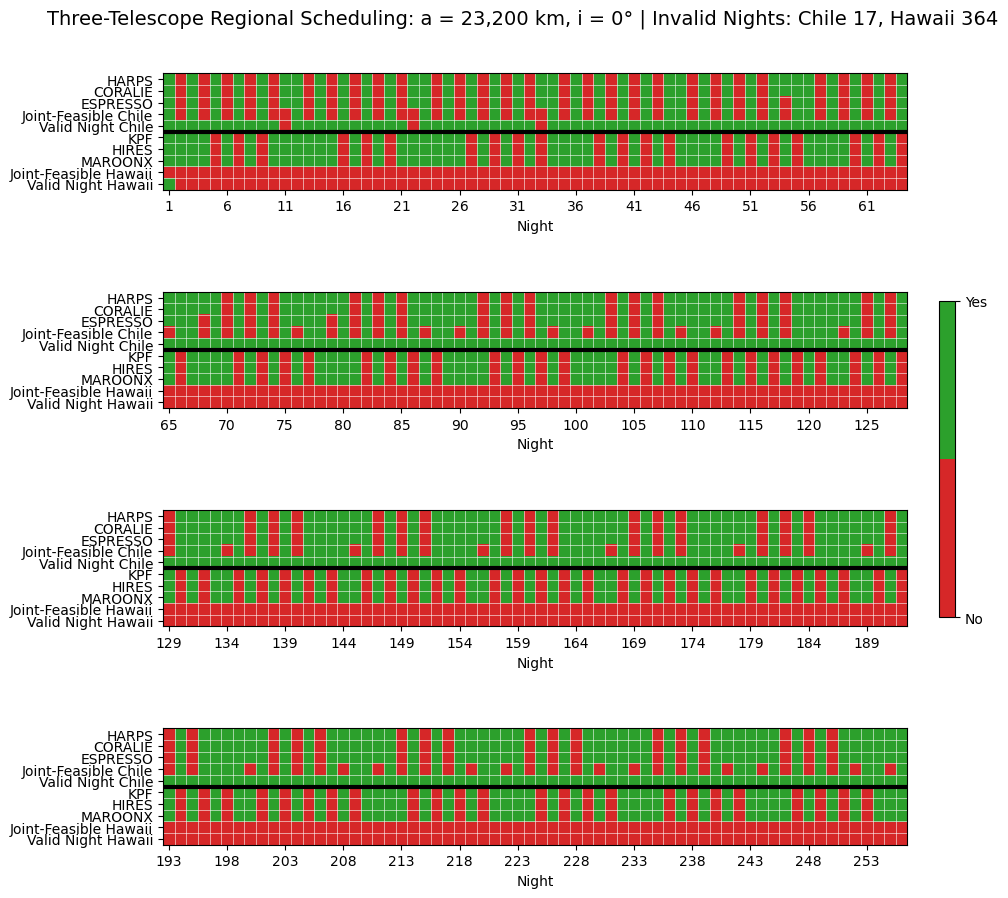

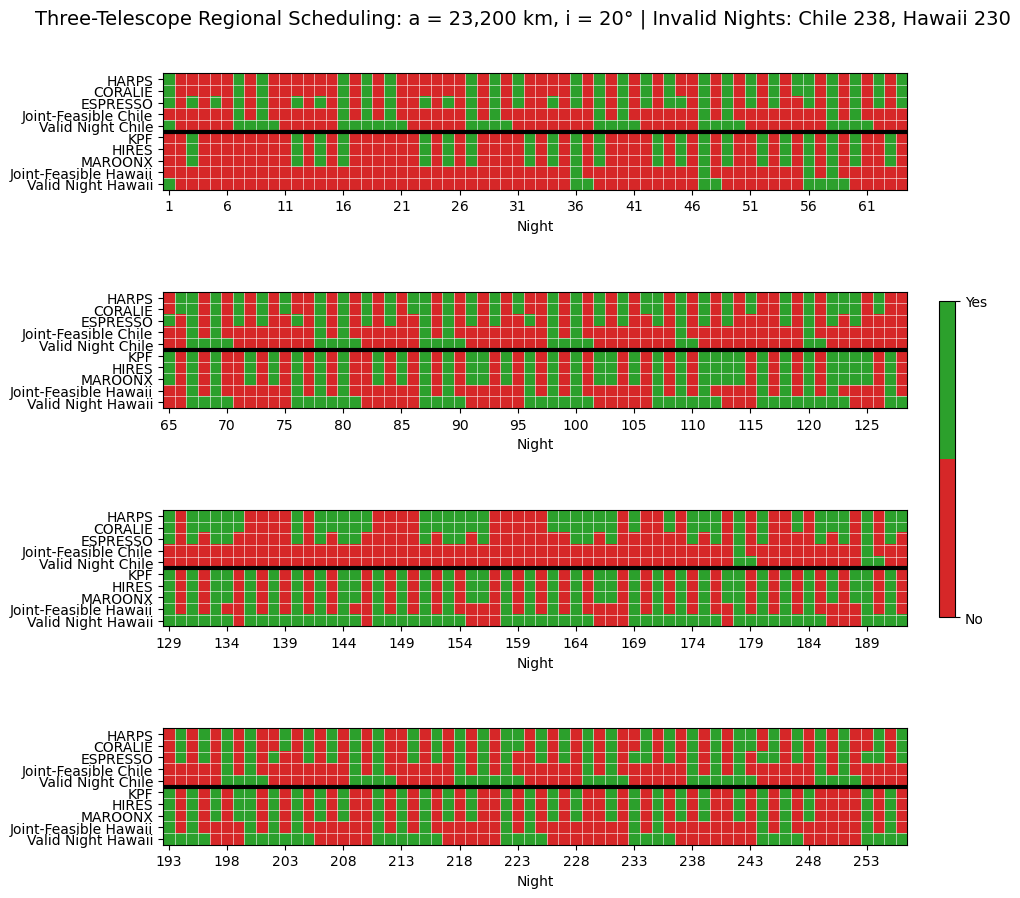

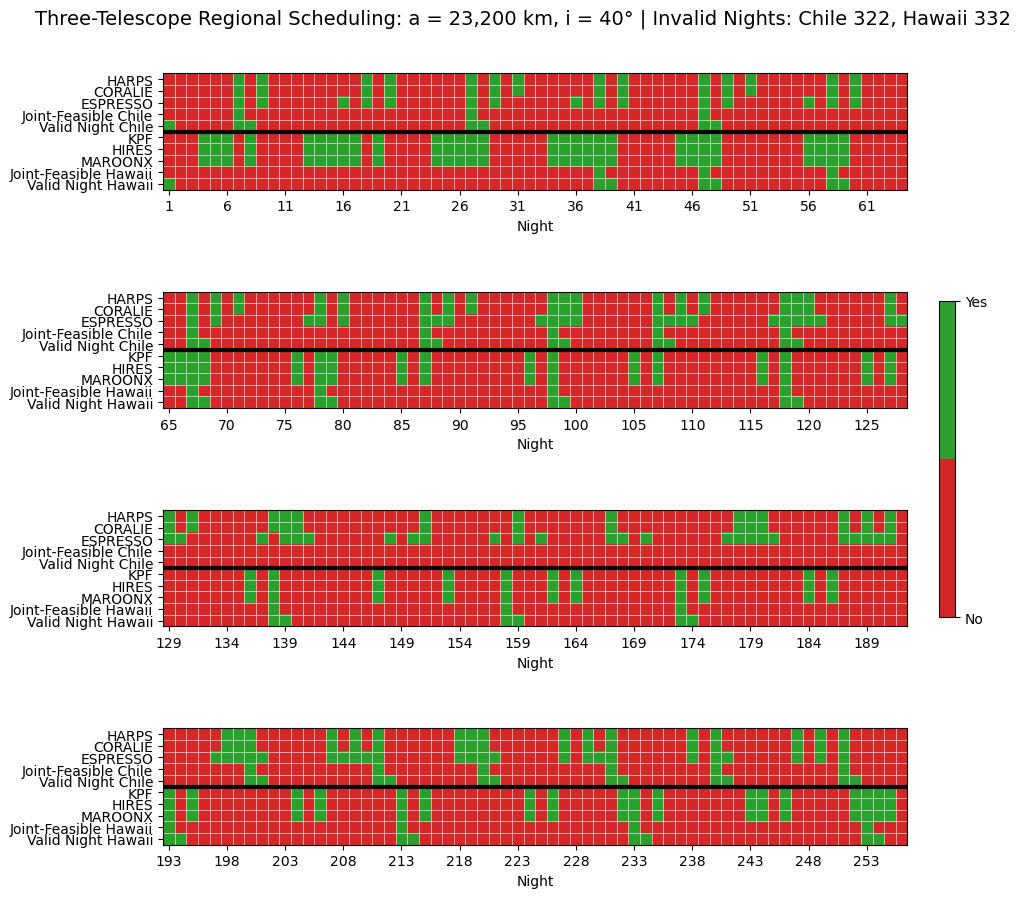

In [27]:
# Combined Chile and Hawaii three-telescope scheduling heatmaps

def plot_regional_status_heatmap(case, status, title, filename, separator_y, figsize):
    """Plot Boolean night status in the existing heatmap format."""
    status_labels = list(status.columns)
    plot_end_night = min(
        PLOT_START_NIGHT
        + THREE_TELESCOPE_NUMBER_OF_PLOTS
        * THREE_TELESCOPE_NIGHTS_PER_PLOT - 1,
        int(status.index.max()))

    fig, axes = plt.subplots(
        THREE_TELESCOPE_NUMBER_OF_PLOTS, 1,
        figsize=figsize,
        gridspec_kw={"hspace": 0.18})

    axes = np.atleast_1d(axes)
    last_image = None
    plotted_any_data = False

    for plot_index, ax in enumerate(axes):
        start_night = PLOT_START_NIGHT + plot_index * THREE_TELESCOPE_NIGHTS_PER_PLOT
        end_night = min(
            start_night + THREE_TELESCOPE_NIGHTS_PER_PLOT - 1,
            plot_end_night)
        night_numbers = np.arange(start_night, end_night + 1)

        if len(night_numbers) == 0:
            ax.set_visible(False)
            continue

        plot_status = status.reindex(night_numbers)

        if plot_status.isna().any(axis=None):
            ax.set_visible(False)
            continue

        plotted_any_data = True
        status_values = plot_status.to_numpy(dtype=int).T

        last_image = ax.imshow(
            status_values, aspect="equal",
            interpolation="nearest",
            cmap=ListedColormap(["#d62728", "#2ca02c"]),
            vmin=0, vmax=1,
            extent=[
                night_numbers[0] - 0.5,
                night_numbers[-1] + 0.5,
                len(status_labels) - 0.5, -0.5])

        ax.set_xlabel("Night")
        ax.set_yticks(range(len(status_labels)))
        ax.set_yticklabels(status_labels)

        ax.set_xticks(np.arange(start_night, end_night + 1, 5))
        ax.set_xticks(
            np.arange(start_night - 0.5, end_night + 0.5, 1),
            minor=True)
        ax.set_yticks(
            np.arange(-0.5, len(status_labels), 1),
            minor=True)

        ax.grid(
            which="minor", color="white",
            linewidth=0.5, alpha=0.8)
        ax.axhline(separator_y, color="black", linewidth=3)
        ax.tick_params(which="minor", bottom=False, left=False)

    if not plotted_any_data:
        plt.close(fig)
        raise ValueError(
            f"The selected plot-night range contains "
            f"no analysed nights for {case['name']}.")

    fig.suptitle(title, fontsize=14, y=0.94)

    fig.subplots_adjust(
        top=0.91, bottom=0.07, left=0.20,
        right=0.86, hspace=0.18)

    visible_axes = [ax for ax in axes if ax.get_visible()]

    colorbar = fig.colorbar(
        last_image, ax=visible_axes, location="right",
        ticks=[0, 1], fraction=0.02, pad=0.04)
    colorbar.ax.set_yticklabels(["No", "Yes"])

    if SAVE_FIGURES:
        output = BASE / "scheduling_plots"
        output.mkdir(parents=True, exist_ok=True)

        plt.savefig(
            output / filename,
            dpi=300, bbox_inches="tight")

    plt.show()


observation_column_suffix = f"≥{MIN_OBSERVATION_H * 60:g} min"

for case in CASES:
    chile_schedule = all_three_telescope_schedules[case["folder"]]["Chile"]
    hawaii_schedule = all_three_telescope_schedules[case["folder"]]["Hawaii"]
    common_nights = min(len(chile_schedule), len(hawaii_schedule))

    chile_plot = chile_schedule.iloc[:common_nights].reset_index(drop=True)
    hawaii_plot = hawaii_schedule.iloc[:common_nights].reset_index(drop=True)

    combined_status = pd.DataFrame({
        "HARPS": chile_plot[f"HARPS {observation_column_suffix}"],
        "CORALIE": chile_plot[f"CORALIE {observation_column_suffix}"],
        "ESPRESSO": chile_plot[f"ESPRESSO {observation_column_suffix}"],
        "Joint-Feasible Chile": chile_plot["3-joint schedule feasible"],
        "Valid Night Chile": chile_plot["Valid night"],
        "KPF": hawaii_plot[f"KPF {observation_column_suffix}"],
        "HIRES": hawaii_plot[f"HIRES {observation_column_suffix}"],
        "MAROONX": hawaii_plot[f"MAROONX {observation_column_suffix}"],
        "Joint-Feasible Hawaii": hawaii_plot["3-joint schedule feasible"],
        "Valid Night Hawaii": hawaii_plot["Valid night"]})

    combined_status.index = np.arange(1, common_nights + 1)
    combined_status.index.name = "Night"

    chile_invalid_nights = int((~chile_schedule["Valid night"]).sum())
    hawaii_invalid_nights = int((~hawaii_schedule["Valid night"]).sum())

    plot_regional_status_heatmap(
        case,
        combined_status,
        f"Three-Telescope Regional Scheduling: {case['name']} | "
        f"Invalid Nights: Chile {chile_invalid_nights}, "
        f"Hawaii {hawaii_invalid_nights}",
        f"three_telescope_regional_schedule_"
        f"a{case['semi_major_axis']}_"
        f"i{case['inclination']}.png",
        separator_y=4.5,
        figsize=(12, 10))

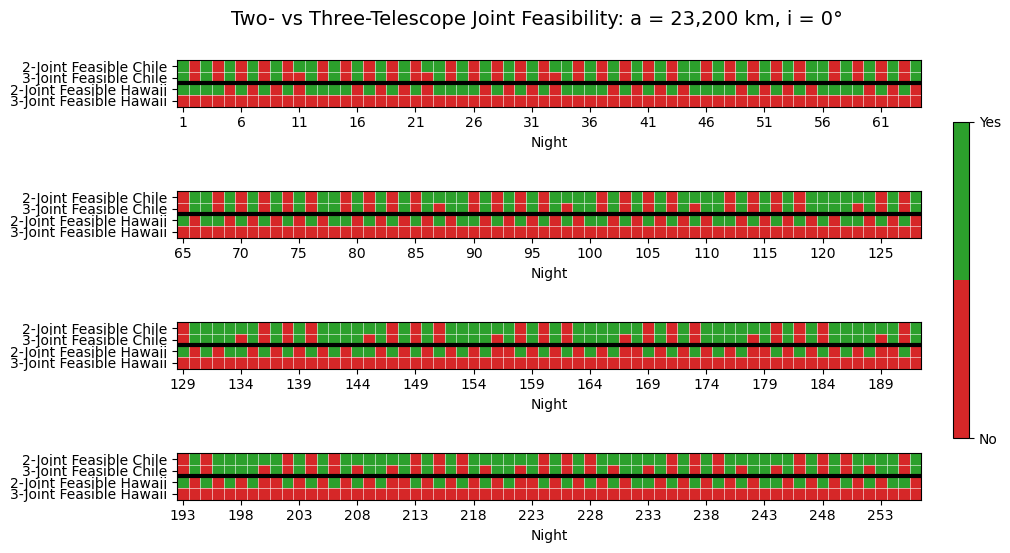

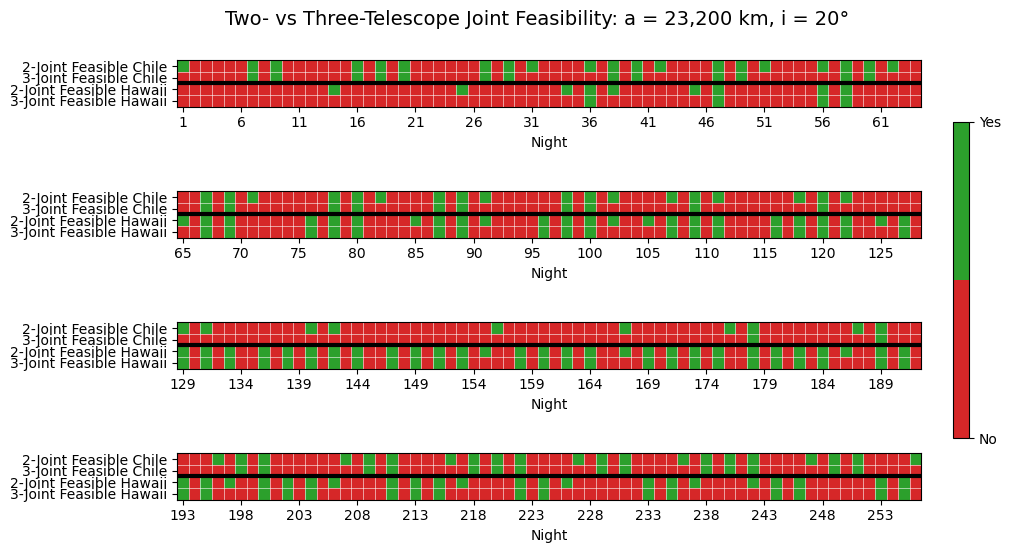

In [23]:
# Two-joint and three-joint feasibility heatmaps

for case in CASES:
    chile_schedule = all_three_telescope_schedules[case["folder"]]["Chile"]
    hawaii_schedule = all_three_telescope_schedules[case["folder"]]["Hawaii"]
    common_nights = min(len(chile_schedule), len(hawaii_schedule))

    chile_plot = chile_schedule.iloc[:common_nights].reset_index(drop=True)
    hawaii_plot = hawaii_schedule.iloc[:common_nights].reset_index(drop=True)

    joint_status = pd.DataFrame({
        "2-Joint Feasible Chile": chile_plot["2-joint schedule feasible"],
        "3-Joint Feasible Chile": chile_plot["3-joint schedule feasible"],
        "2-Joint Feasible Hawaii": hawaii_plot["2-joint schedule feasible"],
        "3-Joint Feasible Hawaii": hawaii_plot["3-joint schedule feasible"]})

    joint_status.index = np.arange(1, common_nights + 1)
    joint_status.index.name = "Night"

    plot_regional_status_heatmap(
        case,
        joint_status,
        f"Two- vs Three-Telescope Joint Feasibility: {case['name']}",
        f"two_vs_three_joint_feasibility_"
        f"a{case['semi_major_axis']}_"
        f"i{case['inclination']}.png",
        separator_y=1.5,
        figsize=(12, 6))

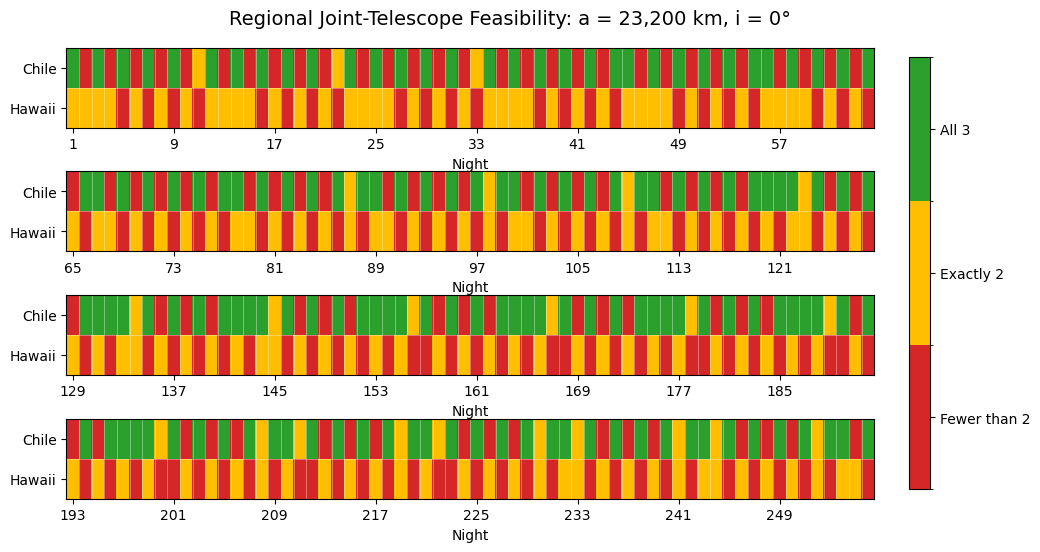

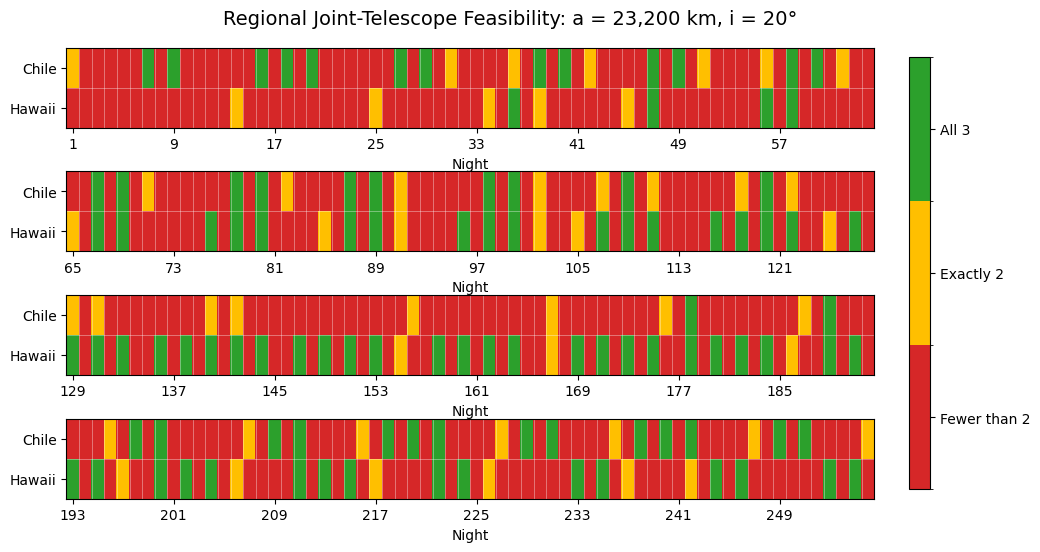

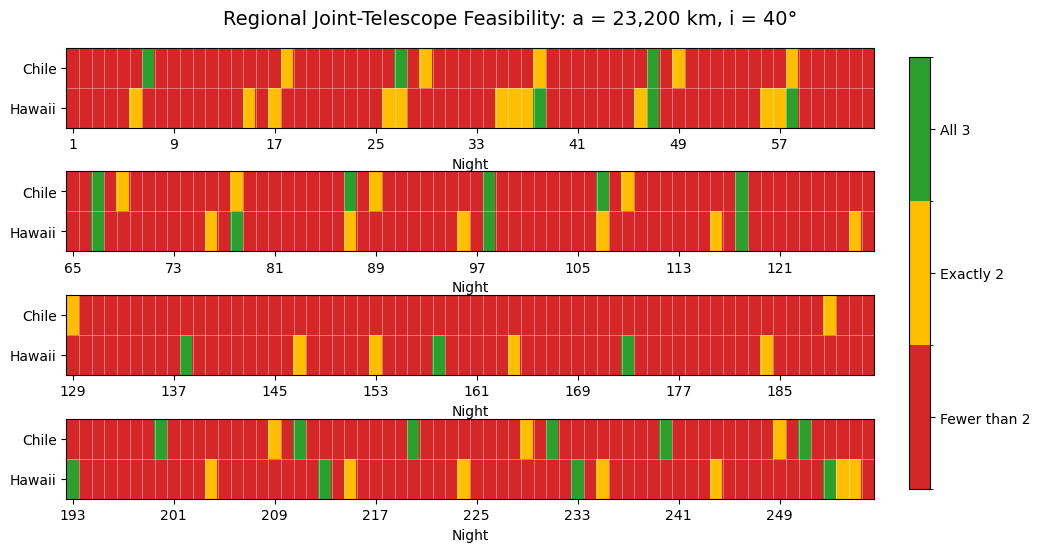

In [29]:
# Two- and three-telescope joint-feasibility heatmaps

from matplotlib.colors import BoundaryNorm

JOINT_STATE_COLORS = ["#d62728", "#ffbf00", "#2ca02c"]
JOINT_STATE_LABELS = ["Fewer than 2", "Exactly 2", "All 3"]
JOINT_STATE_XTICK_STEP = 8


def get_joint_feasibility_state(schedule):
    """Encode each night by the maximum jointly feasible telescope count."""
    two_joint = schedule["2-joint schedule feasible"].to_numpy(dtype=bool)
    three_joint = schedule["3-joint schedule feasible"].to_numpy(dtype=bool)

    return np.where(three_joint, 2, np.where(two_joint, 1, 0))


def plot_joint_feasibility_heatmap(case, status, filename):
    """Plot regional joint feasibility using three categorical states."""
    status_labels = list(status.columns)
    plot_end_night = min(
        PLOT_START_NIGHT
        + THREE_TELESCOPE_NUMBER_OF_PLOTS
        * THREE_TELESCOPE_NIGHTS_PER_PLOT - 1,
        int(status.index.max()))

    cmap = ListedColormap(JOINT_STATE_COLORS)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    fig, axes = plt.subplots(
        THREE_TELESCOPE_NUMBER_OF_PLOTS, 1,
        figsize=(12, 5.5),
        gridspec_kw={"hspace": 0.55})

    axes = np.atleast_1d(axes)
    last_image = None
    plotted_any_data = False

    for plot_index, ax in enumerate(axes):
        start_night = PLOT_START_NIGHT + plot_index * THREE_TELESCOPE_NIGHTS_PER_PLOT
        end_night = min(
            start_night + THREE_TELESCOPE_NIGHTS_PER_PLOT - 1,
            plot_end_night)
        night_numbers = np.arange(start_night, end_night + 1)

        if len(night_numbers) == 0:
            ax.set_visible(False)
            continue

        plot_status = status.reindex(night_numbers)

        if plot_status.isna().any(axis=None):
            ax.set_visible(False)
            continue

        plotted_any_data = True
        status_values = plot_status.to_numpy(dtype=int).T

        last_image = ax.imshow(
            status_values, aspect="auto",
            interpolation="nearest",
            cmap=cmap, norm=norm,
            extent=[
                night_numbers[0] - 0.5,
                night_numbers[-1] + 0.5,
                len(status_labels) - 0.5, -0.5])

        ax.set_xlabel("Night")
        ax.set_yticks(range(len(status_labels)))
        ax.set_yticklabels(status_labels)

        ax.set_xticks(np.arange(
            start_night, end_night + 1,
            JOINT_STATE_XTICK_STEP))
        ax.set_xticks(np.arange(
            start_night - 0.5, end_night + 0.5, 1),
            minor=True)
        ax.set_yticks(np.arange(
            -0.5, len(status_labels), 1),
            minor=True)

        ax.grid(
            which="minor", color="white",
            linewidth=0.4, alpha=0.65)
        ax.tick_params(which="minor", bottom=False, left=False)

    if not plotted_any_data:
        plt.close(fig)
        raise ValueError(
            f"The selected plot-night range contains "
            f"no analysed nights for {case['name']}.")

    fig.suptitle(
        f"Regional Joint-Telescope Feasibility: {case['name']}",
        fontsize=14, y=0.98)

    fig.subplots_adjust(
        top=0.91, bottom=0.09, left=0.13,
        right=0.85, hspace=0.55)

    visible_axes = [ax for ax in axes if ax.get_visible()]

    colorbar = fig.colorbar(
        last_image, ax=visible_axes, location="right",
        boundaries=[-0.5, 0.5, 1.5, 2.5],
        ticks=[0, 1, 2], fraction=0.025, pad=0.04)
    colorbar.ax.set_yticklabels(JOINT_STATE_LABELS)

    if SAVE_FIGURES:
        output = BASE / "scheduling_plots"
        output.mkdir(parents=True, exist_ok=True)

        plt.savefig(
            output / filename,
            dpi=300, bbox_inches="tight")

    plt.show()


for case in CASES:
    chile_schedule = all_three_telescope_schedules[case["folder"]]["Chile"]
    hawaii_schedule = all_three_telescope_schedules[case["folder"]]["Hawaii"]
    common_nights = min(len(chile_schedule), len(hawaii_schedule))

    chile_plot = chile_schedule.iloc[:common_nights].reset_index(drop=True)
    hawaii_plot = hawaii_schedule.iloc[:common_nights].reset_index(drop=True)

    joint_status = pd.DataFrame({
        "Chile": get_joint_feasibility_state(chile_plot),
        "Hawaii": get_joint_feasibility_state(hawaii_plot)})

    joint_status.index = np.arange(1, common_nights + 1)
    joint_status.index.name = "Night"

    plot_joint_feasibility_heatmap(
        case,
        joint_status,
        f"joint_telescope_feasibility_"
        f"a{case['semi_major_axis']}_"
        f"i{case['inclination']}.png")

Case,Region,Fewer than 2 [%],Exactly 2 [%],All 3 [%]
"a = 23,200 km, i = 0°",Chile,37.500000,9.300000,53.200000
"a = 23,200 km, i = 0°",Hawaii,43.600000,56.400000,0.000000
"a = 23,200 km, i = 20°",Chile,72.100000,10.700000,17.300000
"a = 23,200 km, i = 20°",Hawaii,74.800000,6.800000,18.400000
"a = 23,200 km, i = 40°",Chile,88.500000,5.800000,5.800000
"a = 23,200 km, i = 40°",Hawaii,82.500000,13.200000,4.400000


/var/folders/hf/pbkdlnm979x06xc31r2yw39w0000gn/T/ipykernel_4570/1175153468.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


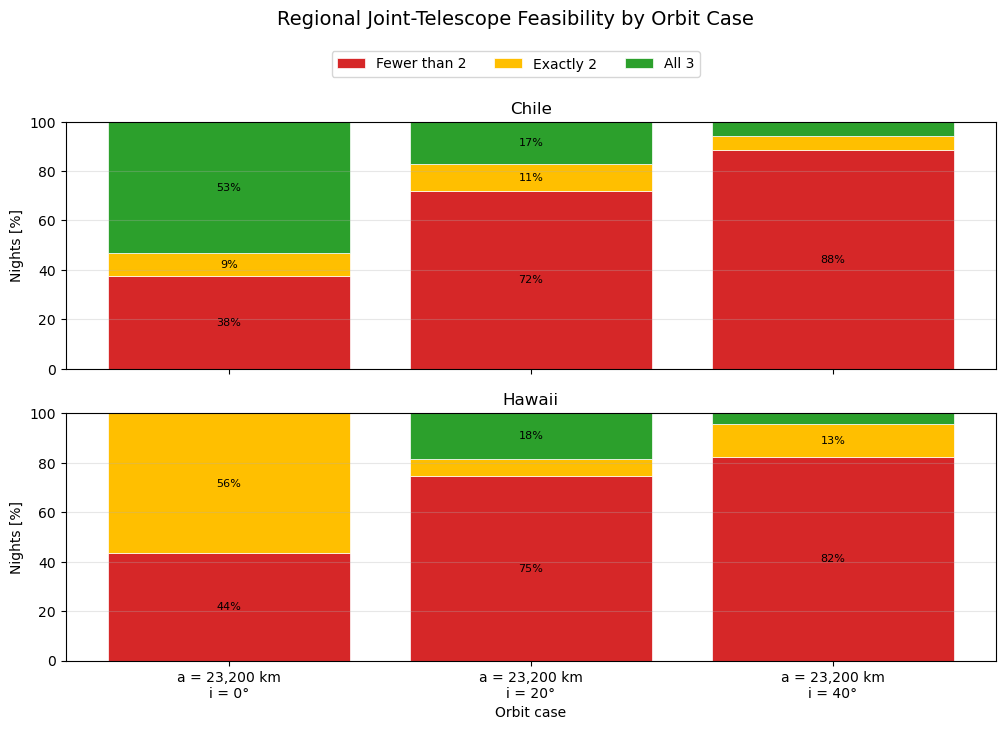

In [30]:
# Regional joint-feasibility percentage summary

joint_state_summary_rows = []

for case in CASES:
    for region_name in REGIONAL_TELESCOPES:
        schedule = all_three_telescope_schedules[case["folder"]][region_name]
        state = get_joint_feasibility_state(schedule)
        number_of_nights = len(state)

        joint_state_summary_rows.append({
            "Case": case["name"],
            "Semi-major axis [km]": case["semi_major_axis"],
            "Inclination [deg]": case["inclination"],
            "Region": region_name,
            "Fewer than 2 [%]": 100 * np.sum(state == 0) / number_of_nights,
            "Exactly 2 [%]": 100 * np.sum(state == 1) / number_of_nights,
            "All 3 [%]": 100 * np.sum(state == 2) / number_of_nights})

joint_state_summary = pd.DataFrame(joint_state_summary_rows)

display(
    joint_state_summary[
        ["Case", "Region", "Fewer than 2 [%]", "Exactly 2 [%]", "All 3 [%]"]
    ].round(1).style.hide(axis="index"))

fig, axes = plt.subplots(
    2, 1, figsize=(12, 7),
    sharex=True,
    gridspec_kw={"hspace": 0.18})

x = np.arange(len(CASES))
case_labels = [
    f"a = {case['semi_major_axis']:,} km\n"
    f"i = {case['inclination']}°"
    for case in CASES]

for ax, region_name in zip(axes, REGIONAL_TELESCOPES):
    region_summary = (
        joint_state_summary[
            joint_state_summary["Region"] == region_name]
        .set_index("Case")
        .reindex([case["name"] for case in CASES]))

    bottom = np.zeros(len(CASES))

    for column, label, color in zip(
        ["Fewer than 2 [%]", "Exactly 2 [%]", "All 3 [%]"],
        JOINT_STATE_LABELS,
        JOINT_STATE_COLORS):

        values = region_summary[column].to_numpy()

        bars = ax.bar(
            x, values, bottom=bottom,
            color=color, edgecolor="white",
            linewidth=0.5, label=label)

        for bar, value, lower in zip(bars, values, bottom):
            if value >= 7:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    lower + value / 2,
                    f"{value:.0f}%",
                    ha="center", va="center",
                    fontsize=8)

        bottom += values

    ax.set_ylabel("Nights [%]")
    ax.set_title(region_name)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(case_labels)
axes[-1].set_xlabel("Orbit case")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=3)

fig.suptitle(
    "Regional Joint-Telescope Feasibility by Orbit Case",
    fontsize=14, y=1.04)

fig.tight_layout()

if SAVE_FIGURES:
    output = BASE / "scheduling_plots"
    output.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        output / "joint_telescope_feasibility_summary.png",
        dpi=300, bbox_inches="tight")

if SAVE_TABLES:
    output = BASE / "scheduling_tables"
    output.mkdir(parents=True, exist_ok=True)

    joint_state_summary.to_csv(
        output / "joint_telescope_feasibility_summary.csv",
        index=False)

plt.show()

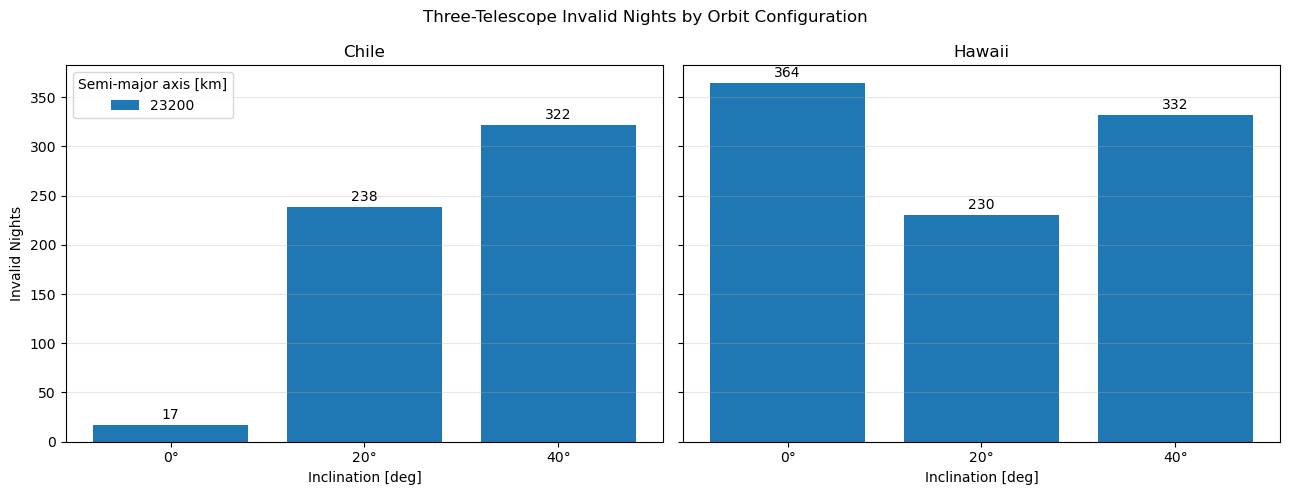

In [31]:
# Invalid nights by orbit configuration for three-telescope regions

case_parameters = pd.DataFrame([{
    "Case": case["name"],
    "Semi-major axis [km]": case["semi_major_axis"],
    "Inclination [deg]": case["inclination"]}
    for case in CASES])

regional_invalid_nights = three_telescope_summaries.merge(
    case_parameters, on="Case", how="left")

semi_major_axes = sorted(regional_invalid_nights["Semi-major axis [km]"].unique())
inclinations = sorted(regional_invalid_nights["Inclination [deg]"].unique())
regions = ["Chile", "Hawaii"]

x = np.arange(len(inclinations))
bar_width = 0.8 / len(semi_major_axes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, region_name in zip(axes, regions):
    region_data = regional_invalid_nights[
        regional_invalid_nights["Region"] == region_name]

    for axis_index, semi_major_axis in enumerate(semi_major_axes):
        values = []

        for inclination in inclinations:
            matching_row = region_data[
                (region_data["Semi-major axis [km]"] == semi_major_axis)
                & (region_data["Inclination [deg]"] == inclination)]

            values.append(
                int(matching_row["Invalid Nights"].iloc[0])
                if not matching_row.empty else np.nan)

        bar_positions = x + (axis_index - (len(semi_major_axes) - 1) / 2) * bar_width
        bars = ax.bar(
            bar_positions, values, width=bar_width,
            label=f"{semi_major_axis:g}")

        for bar, value in zip(bars, values):
            if np.isnan(value):
                continue

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 3,
                f"{int(value)}",
                ha="center", va="bottom")

    ax.set_title(region_name)
    ax.set_xlabel("Inclination [deg]")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{inclination:g}°" for inclination in inclinations])
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Invalid Nights")
axes[0].legend(title="Semi-major axis [km]")

fig.suptitle("Three-Telescope Invalid Nights by Orbit Configuration")
fig.tight_layout()

if SAVE_FIGURES:
    output = BASE / "scheduling_plots"
    output.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        output / "three_telescope_invalid_nights_by_orbit.png",
        dpi=300, bbox_inches="tight")

plt.show()